# Q9
### Q9. Simple Customer Support Chatbot using LangGraph Multi-Agent Workflow

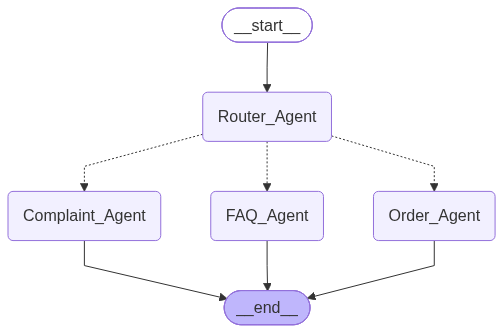

User Query: I received a damaged product
Category: complaint
Bot Response: We’re very sorry to hear that your product arrived damaged. We understand how disappointing this must be, and we appreciate you bringing it to our attention.

**Next steps:**

1. **Document the damage** – Please take clear photos of the damaged item and its packaging.  
2. **Contact our returns team** – Reply to this message with the photos attached, or reach out to support@example.com and include your order number.  
3. **Choose a resolution** – Let us know whether you’d prefer a replacement shipped to you or a full refund.  
4. **Return the item (if needed)** – If we need the damaged product back, we’ll provide a prepaid shipping label and instructions.

Once we receive the photos and your preference, we’ll process the replacement or refund promptly (usually within 1–2 business days). Thank you for your patience, and again we apologize for the inconvenience. If you have any other questions, please let us know.

In [17]:
%pip install -U langgraph langchain langchain-core langchain-groq ipython

import os
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from IPython.display import Image, display

# Add your Groq API key
os.environ["GROQ_API_KEY"] = "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"

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

class ChatState(TypedDict):
    query: str
    category: str
    response: str

def router_agent(state):
    query = state["query"]

    prompt = f"""
Classify this customer query into one category:
faq, order, or complaint.

Query: {query}

Return only one word.
"""
    result = llm.invoke([HumanMessage(content=prompt)])
    category = result.content.strip().lower()

    if "order" in category:
        category = "order"
    elif "complaint" in category:
        category = "complaint"
    else:
        category = "faq"

    return {"category": category}

def faq_agent(state):
    query = state["query"]

    prompt = f"""
You are an FAQ support agent.
Answer this customer question politely:

{query}
"""
    result = llm.invoke([HumanMessage(content=prompt)])
    return {"response": result.content}

def order_agent(state):
    query = state["query"]

    prompt = f"""
You are an order support agent.
Help the customer with order-related query.
If order ID is missing, ask for it politely.

Query: {query}
"""
    result = llm.invoke([HumanMessage(content=prompt)])
    return {"response": result.content}

def complaint_agent(state):
    query = state["query"]

    prompt = f"""
You are a complaint support agent.
Apologize politely and suggest the next step.

Complaint: {query}
"""
    result = llm.invoke([HumanMessage(content=prompt)])
    return {"response": result.content}

def route(state):
    if state["category"] == "order":
        return "Order_Agent"
    elif state["category"] == "complaint":
        return "Complaint_Agent"
    else:
        return "FAQ_Agent"

workflow = StateGraph(ChatState)

workflow.add_node("Router_Agent", router_agent)
workflow.add_node("FAQ_Agent", faq_agent)
workflow.add_node("Order_Agent", order_agent)
workflow.add_node("Complaint_Agent", complaint_agent)

workflow.set_entry_point("Router_Agent")

workflow.add_conditional_edges(
    "Router_Agent",
    route,
    {
        "FAQ_Agent": "FAQ_Agent",
        "Order_Agent": "Order_Agent",
        "Complaint_Agent": "Complaint_Agent"
    }
)

workflow.add_edge("FAQ_Agent", END)
workflow.add_edge("Order_Agent", END)
workflow.add_edge("Complaint_Agent", END)

app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))

# Test chatbot
query = "I received a damaged product"

result = app.invoke({
    "query": query,
    "category": "",
    "response": ""
})

print("User Query:", query)
print("Category:", result["category"])
print("Bot Response:", result["response"])

### Q11. Develop an AI Research Agent with Autogen

In [ ]:
%pip install -q -U autogen groq 
%pip install "ag2[openai]"

import os
from autogen import AssistantAgent, UserProxyAgent

# ------------------------------------
# 1. Set Groq API Key
# ------------------------------------
os.environ["GROQ_API_KEY"] = "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"

# ------------------------------------
# 2. Configure LLMgsk_Sf9lCY5TSSUDWrVilKfoWGdyb3FYVJ4arJBpbFKHt49pqfyPZuo0
# ------------------------------------
llm_config = {
    "config_list": [
        {
            "model": "openai/gpt-oss-20b",
            "api_key": os.environ["GROQ_API_KEY"],
            "base_url": "https://api.groq.com/openai/v1"
        }
    ]
}

# ------------------------------------
# 3. Create AI Research Agent
# ------------------------------------
research_agent = AssistantAgent(
    name="Research_Agent",
    system_message="""
You are an AI Research Agent.

Your task is to:
1. Study the given research topic.
2. Identify important concepts and recent trends.
3. Summarize key methods and applications.
4. Discuss advantages and limitations.
5. Present the findings in a clear research-report format.
""",
    llm_config=llm_config,
)

# ------------------------------------
# 4. Create User Proxy Agent
# ------------------------------------
user_proxy = UserProxyAgent(
    name="User_Proxy",

    # No human input during execution
    human_input_mode="NEVER",

    code_execution_config={
        "work_dir": "research",
        "use_docker": False
    }
)

# ------------------------------------
# 5. Start Research Task
# ------------------------------------
user_proxy.initiate_chat(
    research_agent,
    message="""
Research the topic:

"Applications of Generative AI in Healthcare"

Prepare a short research report containing:
- Introduction
- Important applications
- Benefits
- Challenges
- Future scope
- Conclusion
"""
)

User_Proxy (to Research_Agent):


Research the topic:

"Applications of Generative AI in Healthcare"

Prepare a short research report containing:
- Introduction
- Important applications
- Benefits
- Challenges
- Future scope
- Conclusion


--------------------------------------------------------------------------------
[autogen.oai.client: 08-27 11:50:26] {734} WARNING - Model openai/gpt-oss-20b is not found. The cost will be 0. In your config_list, add field {"price" : [prompt_price_per_1k, completion_token_price_per_1k]} for customized pricing.
Research_Agent (to User_Proxy):

**Applications of Generative AI in Healthcare**  
*A concise research report*

---

## 1. Introduction  

Generative Artificial Intelligence (GenAI) – encompassing diffusion models, variational autoencoders (VAEs), transformers, and generative adversarial networks (GANs) – has moved beyond “image‑style transfer” to become a transformative tool in medicine. By learning the underlying distribution of biomedical d